In [27]:
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from util import omi_utils
from util import MJO_indices_util as mjo
import mjoindices.empirical_orthogonal_functions as eof

%load_ext autoreload
%autoreload 2   

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Create OLR anomalies 

In [11]:
olrfile = '/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/olr.day.mean.nc'

olrano = mjo.get_anomalies_1var('olr', olrfile, None, None, latsel=90, yearclim_sta=1979, yearclim_end=2012)
olrano = olrano.drop('dayofyear')

dataset = olrano.to_dataset(name='olr')
dataset.to_netcdf('/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/olr.ano.mean.nc', mode='w')

start compute: olr
shape of raw climatological maps:  (366, 73, 144)


In [18]:
olrfile = '/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/olr.ano.mean.nc'
ds = xr.open_dataset(olrfile)
olrano = ds['olr']

olr_rt_noac = np.copy(np.squeeze(olrano.values)) 
olr_rt_noac_sm = np.zeros(olr_rt_noac.shape)

for it in np.arange(40, olr_rt_noac.shape[0]):
    olr_rt_noac_sm[it,:,:] = olr_rt_noac[it,:,:] - olr_rt_noac[it-40:it,:,:].mean(0)

olr_rt_noac_sm_tapavg = np.empty(olr_rt_noac_sm.shape)

for ii in np.arange(olr_rt_noac_sm_tapavg.shape[1]):
    for jj in np.arange(olr_rt_noac_sm_tapavg.shape[2]):
        olr_rt_noac_sm_tapavg[:, ii, jj]  = omi_utils.runningMeanFast_conv(olr_rt_noac_sm[:, ii, jj], 9)

olrano.values = olr_rt_noac_sm_tapavg



In [19]:
dataset = olrano.to_dataset(name='olr')
dataset.to_netcdf('/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/olr.anopls.mean.nc', mode='w')

In [24]:
ds = xr.open_dataset('/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/olr.anopls.mean.nc')
olranopls = ds['olr'].sel(time='2000-10-10')

ds = xr.open_dataset('/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/olr.ano.mean.nc')
olrano = ds['olr'].sel(time='2000-10-10')

ds = xr.open_dataset('/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/olr.day.mean.nc')
olr = ds['olr'].sel(time='2000-10-10')


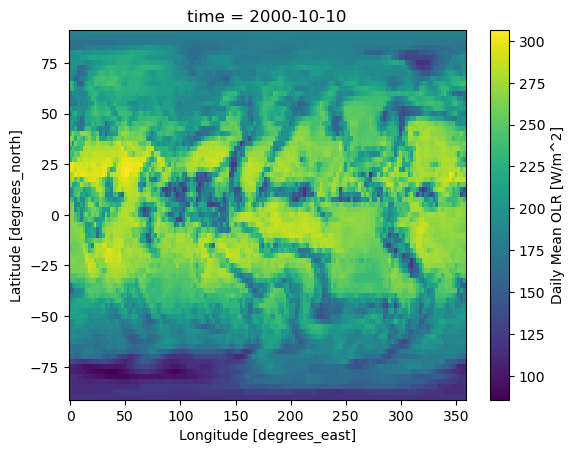

In [25]:
olr.plot()


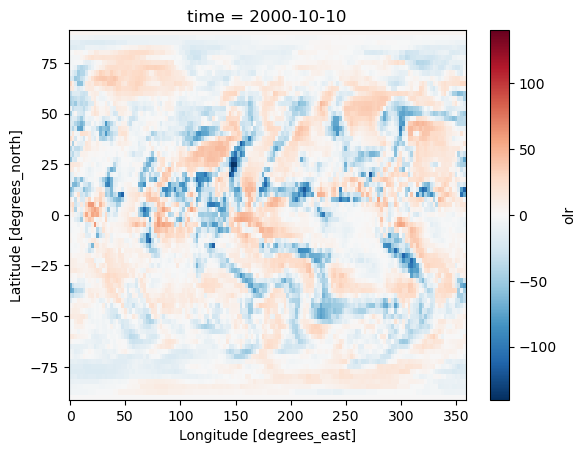

In [23]:
olrano.plot()

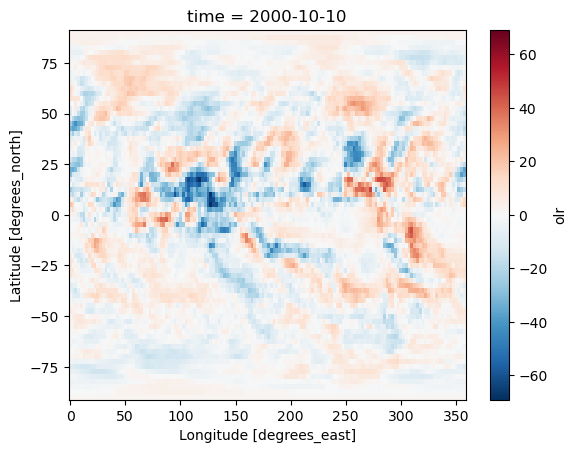

In [26]:
olranopls.plot()

### Calculate ROMI using NOAA interpolated OLR

In [2]:
olrfile = '/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/olr.day.mean.nc'

olr_rt_noac_sm_tapavg, ttime, olons, olats = omi_utils.get_olr4omi(olrDataFile=olrfile)
mjo_mode = omi_utils.get_omi_eofs(olons,olats)
mjo_rt2 = omi_utils.calc_romi(olr_rt_noac_sm_tapavg, ttime, mjo_mode)

date_sta = datetime.datetime(1979, 1, 1)
date_end = datetime.datetime(2022, 12, 31)

ind_sta = ttime.index(date_sta)
ind_end = ttime.index(date_end)

ofac = np.std(mjo_rt2[ind_sta:ind_end,0])
print(ofac)
momi_1 = mjo_rt2[:,0]/ofac
momi_2 = mjo_rt2[:,1]/ofac
pha = np.arctan2(-momi_1, momi_2)
momi_time = ttime
momi_rt_phase = np.floor((pha+np.pi)/(np.pi/4)).astype(int)
momi_rt_phase += 1
momi_rt_amp = np.sqrt(momi_1**2 + momi_2**2)

# form the arrays and save it to a text file
dyear = np.array([t.year for t in ttime])[:,np.newaxis]
dmonth = np.array([t.month for t in ttime])[:,np.newaxis]
dday = np.array([t.day for t in ttime])[:,np.newaxis]
date_arr = np.concatenate((dyear, dmonth, dday), axis=1 )
X = np.concatenate((date_arr, momi_1[:,None], momi_2[:,None], momi_rt_amp[:,None], momi_rt_phase[:,None]), axis=1)

np.savetxt('ROMI_NOAA.txt', X, fmt='%4d   %2d   %2d  %10.2f  %10.2f  %10.2f  %1d')

start compute: olr
shape of raw climatological maps:  (366, 17, 144)
224.8542184106459


In [3]:
txt_fn = 'ROMI_NOAA.txt'
df = pd.read_csv(txt_fn, header=None,sep="\s+", names=['Year', 'Month', 'Day', 'PC1', 'PC2', 'amp', 'phase'])
df['time'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df = df.set_index('time').drop(columns=['Year', 'Month', 'Day'])
ROMI_values = np.empty((len(df), 2))
ROMI_values[:, 0] = df['PC1'].values
ROMI_values[:, 1] = df['PC2'].values

ROMI = xr.DataArray(ROMI_values, dims=['time', 'mode'], coords={'time': df.index.values})

ds = xr.Dataset({'ROMI': ROMI})
ds.attrs['description'] = 'ROMI calculated using OLR from NOAA; 2.5x2.5 grid \n' + \
                            '2024/11/04 created by Lin Yao'   

ds.to_netcdf('/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/ROMI/ROMI_NOAA_1979to2022.nc', mode='w')

In [36]:
fn_noaa = '/pscratch/sd/l/linyaoly/MJO_data_2.5x2.5/NOAA/ROMI/ROMI_NOAA_1979to2022.nc'
ds = xr.open_dataset(fn_noaa)
ROMI = ds['ROMI']

In [37]:
fn_era5 = '/pscratch/sd/l/linyaoly/ERA5/reanalysis/rmm/full/ROMI_ERA5_daily_1979to2014.nc'
ds_era5 = xr.open_dataset(fn_era5)
ROMI_era5 = ds_era5['ROMI']

In [38]:
fn_web = 'ROMI_web.txt'
df_web = pd.read_csv(fn_web, header=None,sep="\s+", names=['Year', 'Month', 'Day', 'Hour', 'PC1', 'PC2', 'amp'])


In [39]:
df_web['time'] = pd.to_datetime(df_web[['Year', 'Month', 'Day', 'Hour']])
df_web = df_web.set_index('time').drop(columns=['Year', 'Month', 'Day', 'Hour'])
ds_web = df_web.to_xarray()
ds_web

<xarray.Dataset>
Dimensions:  (time: 12360)
Coordinates:
  * time     (time) datetime64[ns] 1991-01-01 1991-01-02 ... 2024-11-02
Data variables:
    PC1      (time) float64 0.1253 0.1854 0.2396 ... -0.9291 -0.8664 -0.8379
    PC2      (time) float64 -0.06945 -0.04887 -0.03933 ... -1.318 -1.197 -1.106
    amp      (time) float64 0.1432 0.1918 0.2428 0.2752 ... 1.612 1.477 1.388

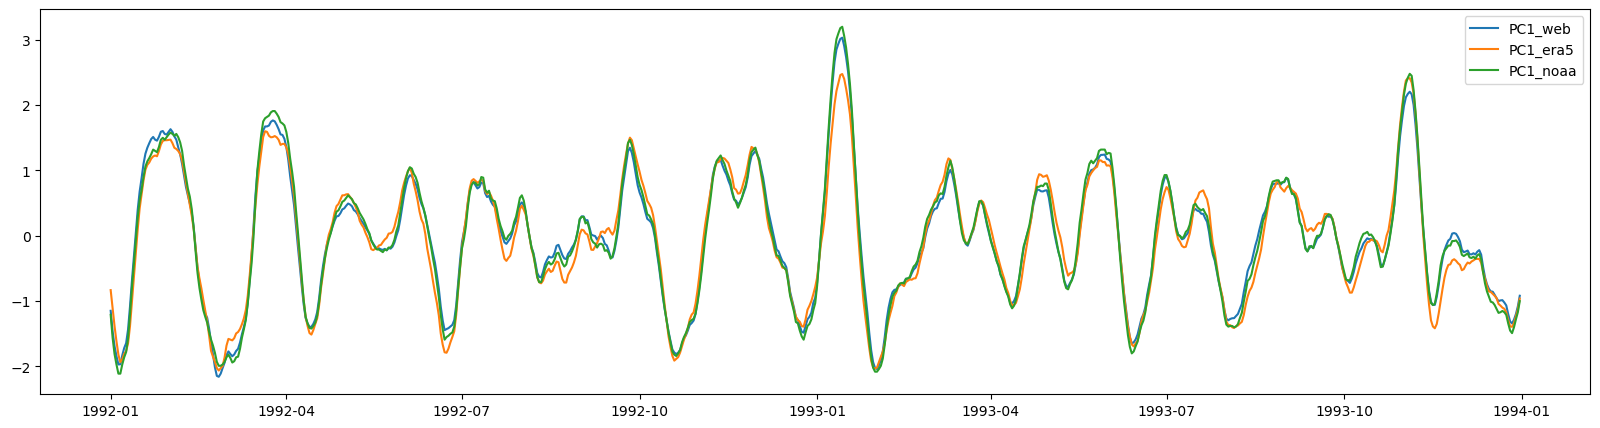

In [40]:
ds_web_sel = ds_web.sel(time=slice('1992-01-01', '1993-12-31'))
ds_era5_sel = ds_era5.sel(time=slice('1992-01-01', '1993-12-31'))
ds_sel = ds.sel(time=slice('1992-01-01', '1993-12-31'))
fig, ax = plt.subplots()
fig.set_size_inches(20, 5)
ax.plot(ds_web_sel.time, ds_web_sel.PC1, label='PC1_web')
ax.plot(ds_era5_sel.time, ds_era5_sel.ROMI[:,0].values, label='PC1_era5')
ax.plot(ds_sel.time, ds_sel.ROMI[:,0].values, label='PC1_noaa')
# ax.plot(ds.time, ds.PC2, label='PC2_NOAA')

ax.legend()

In [8]:
# correlation during 2000 - 2022
ds_web_sel = ds_web.sel(time=slice('1991-01-01', '1992-12-31'))
ds_sel = ds.sel(time=slice('1991-01-01', '1992-12-31'))

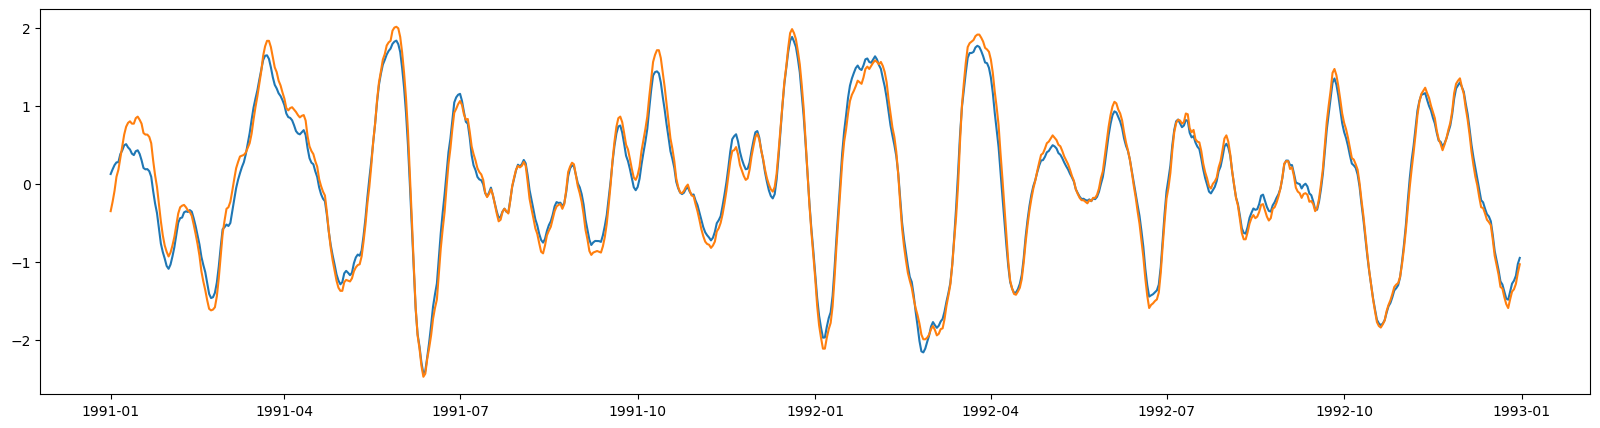

In [9]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 5)
ax.plot(ds_web_sel.time, ds_web_sel.PC1, label='PC1_web')
# ax.plot(ds_web.time, ds_web.PC2, label='PC2_web')
ax.plot(ds_sel.time, ds_sel.ROMI[:,0].values, label='PC1_NOAA')
# ax.plot(ds.time, ds.PC2, label='PC2_NOAA')


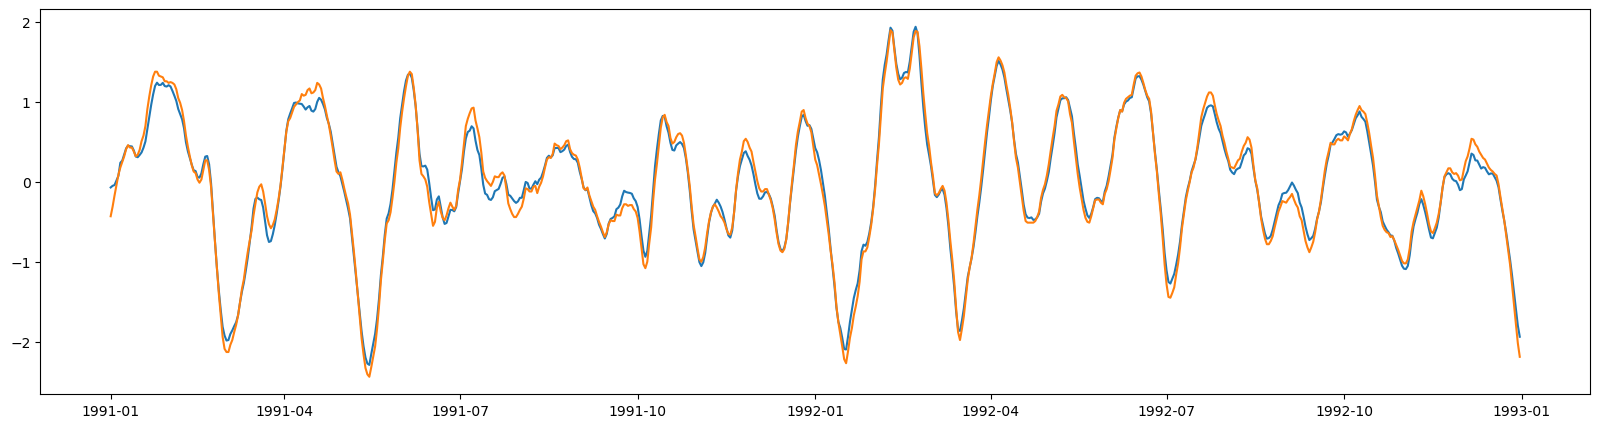

In [53]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 5)
# ax.plot(ds_web_sel.time, ds_web_sel.PC1, label='PC1_web')
ax.plot(ds_web_sel.time, ds_web_sel.PC2, label='PC2_web')
# ax.plot(ds_sel.time, ds_sel.PC1, label='PC1_NOAA')
ax.plot(ds_sel.time, ds_sel.PC2, label='PC2_NOAA')


In [ ]:

ds 

<xarray.Dataset>
Dimensions:  (time: 16071, mode: 2)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-01-02 ... 2022-12-31
Dimensions without coordinates: mode
Data variables:
    ROMI     (time, mode) float64 0.1418 0.7832 -0.00861 ... -0.9955 0.8612
Attributes:
    description:  ROMI calculated using OLR from NOAA; 2.5x2.5 grid \n2024/11...

In [22]:
dssel = ds.sel(time=slice('1991','1991'))